### ⭐ Exercise 1 — "Outlier Detective" 🕵️
Take this salary list `[40, 42, 38, 41, 39, 43, 500]`. Compute mean, median, and std. Then remove
the outlier and recompute. Write one sentence on which measure of center you'd report to your boss, and why.

Answer: I would report the median(41) because it is not affected by extreme
        outliers and better represents the typical salary.

In [1]:
import numpy as np

# Original data (with outlier)
salaries = np.array([40, 42, 38, 41, 39, 43, 500])

print("=====with outlier=====")
print("Mean:", np.mean(salaries))
print("Median:", np.median(salaries))
print("Std Dev:", np.std(salaries))

# Remove outlier (500)
salaries_no_outlier = np.array([40, 42, 38, 41, 39, 43])

print("\n=====without outlier=====")
print("Mean:", np.mean(salaries_no_outlier))
print("Median:", np.median(salaries_no_outlier))
print("Std Dev:", np.std(salaries_no_outlier))

print("\nLesson: when data has outliers, the MEDIAN often describes the 'typical' value better.")


=====with outlier=====
Mean: 106.14285714285714
Median: 41.0
Std Dev: 160.79927911301502

=====without outlier=====
Mean: 40.5
Median: 40.5
Std Dev: 1.707825127659933

Lesson: when data has outliers, the MEDIAN often describes the 'typical' value better.


### ⭐ Exercise 2 — "Loaded Dice Casino" 🎲
Simulate 10,000 rolls of a **fair** die and 10,000 of a **loaded** die (where 6 appears twice as
often as other faces). Plot both PMFs side by side. Does the loaded die's average differ from 3.5?

Answer:
      Observation:
          Fair die → all probabilities equal
          Loaded die → face 6 has higher probability

          Mean Calculation:

          Fair die mean = 3.5
          Loaded die mean ≈ 3.86

          the loaded die’s average differs from 3.5. It is higher (≈3.86) because the outcome 6 occurs more frequently than other faces.

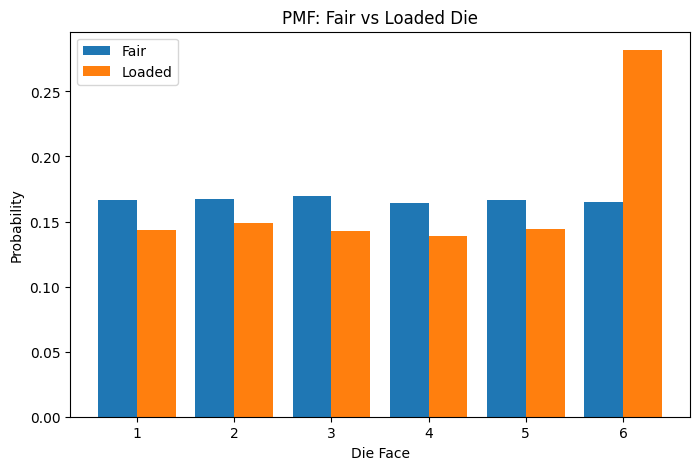

Fair mean: 3.4917
Loaded mean: 3.8374


In [2]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng()

# 1. Simulate rolls
fair = rng.integers(1, 7, size=10000)

faces = np.array([1,2,3,4,5,6])
probs = np.array([1,1,1,1,1,2]) / 7   # loaded die
loaded = rng.choice(faces, size=10000, p=probs)

# 2. Count frequencies
fair_counts = [np.sum(fair == i) for i in range(1,7)]
loaded_counts = [np.sum(loaded == i) for i in range(1,7)]

# 3. Convert to PMF
fair_pmf = np.array(fair_counts) / 10000
loaded_pmf = np.array(loaded_counts) / 10000

# 4. Plot
x = np.arange(1,7)

plt.figure(figsize=(8,5))
plt.bar(x - 0.2, fair_pmf, width=0.4, label='Fair')
plt.bar(x + 0.2, loaded_pmf, width=0.4, label='Loaded')

plt.xlabel("Die Face")
plt.ylabel("Probability")
plt.title("PMF: Fair vs Loaded Die")
plt.legend()
plt.show()

# 5. Averages
print("Fair mean:", fair.mean())
print("Loaded mean:", loaded.mean())

### ⭐⭐ Exercise 3 — "Spam Filter Bayes" 📧
The word "FREE" appears in 60% of spam and 5% of real emails. 20% of all emails are spam. An email
contains "FREE" — use **Bayes' theorem** to compute the probability it's spam. Then verify by
simulating 100,000 emails. (Hint: this is exactly the medical-test example in disguise.)


Answer:
      If an email contains “FREE”, then there is a 75% chance that it is spam.



In [3]:
import numpy as np

N = 100000

# Step 1: 20% spam, 80% real
is_spam = np.random.choice([1, 0], size=N, p=[0.2, 0.8])

# Step 2: Assign "FREE" occurrence based on spam/real probability

free = []

for i in range(N):
    if is_spam[i] == 1:
        free.append(np.random.rand() < 0.6)   # spam → 60%
    else:
        free.append(np.random.rand() < 0.05)  # real → 5%

free = np.array(free)

# Step 3: Find spam probability among emails that contain "FREE"
free_emails = free == True
answer = is_spam[free_emails].mean()

print("P(Spam | FREE) =", round(answer, 3))

P(Spam | FREE) = 0.754


### ⭐⭐ Exercise 4 — "CLT With Your Own Weird Distribution" 🎨
Invent a strange distribution (e.g. mix two uniforms, or use `rng.exponential`). Recreate the CLT
experiment: plot the original, then the distribution of sample means for n = 2, 10, 50. Confirm the
means look normal even though your source doesn't.

Answer :
        Observation:
           The original distribution is highly skewed (not normal)
           For n=2: still slightly skewed
           For n=10: becomes smoother
           For n=50: looks almost perfectly normal (bell-shaped)

           Even though the original exponential distribution is not normal, the distribution of sample means becomes approximately normal as sample size increases. This confirms the Central Limit Theorem.


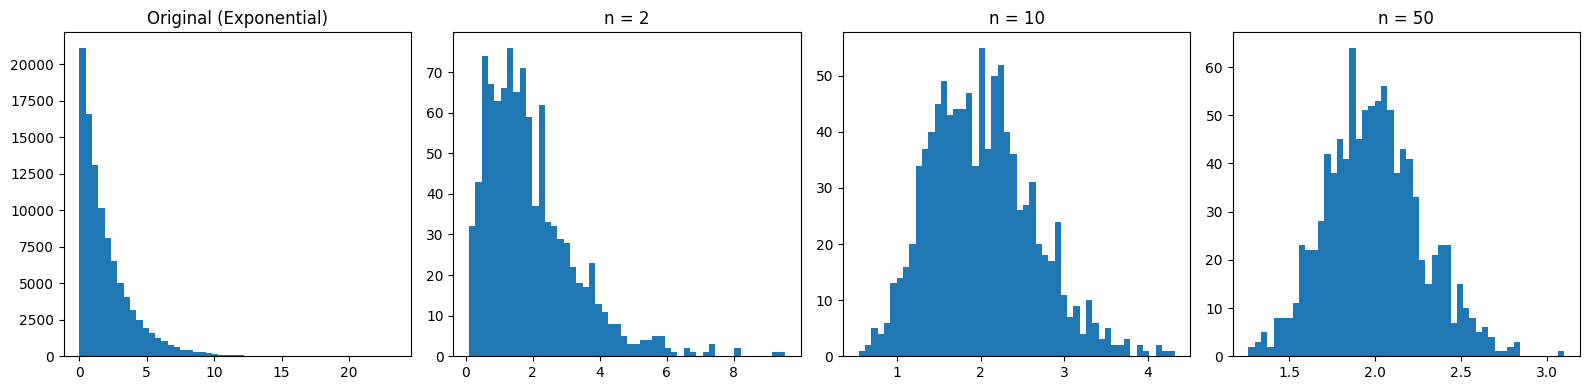

In [4]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)

# -------- Step 1: Strange distribution (Exponential) --------
population = rng.exponential(scale=2.0, size=100000)

# -------- Step 2: Function to compute sample means --------
def sample_means(data, n, num_samples=1000):
    means = []
    for _ in range(num_samples):
        sample = rng.choice(data, size=n)
        means.append(sample.mean())
    return np.array(means)

# Sample means for different n
means_n2 = sample_means(population, 2)
means_n10 = sample_means(population, 10)
means_n50 = sample_means(population, 50)

# -------- Step 3: Plot --------
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Original distribution
axes[0].hist(population, bins=50)
axes[0].set_title("Original (Exponential)")

# Sample means
axes[1].hist(means_n2, bins=50)
axes[1].set_title("n = 2")

axes[2].hist(means_n10, bins=50)
axes[2].set_title("n = 10")

axes[3].hist(means_n50, bins=50)
axes[3].set_title("n = 50")

plt.tight_layout()
plt.show()

### ⭐⭐ Exercise 5 — "Run Your Own A/B Test" 🧪
You run a button-colour test. Green: 500 visitors, 60 clicks. Blue: 500 visitors, 78 clicks.
Use `stats.ttest_ind` to decide if blue is significantly better (p < 0.05). Then *halve* both
sample sizes and re-run — does your conclusion change? What does that teach you about test duration?

Answer:
        Observation:
        Full data → p < 0.05 → significant
        Half data → p increases → may become not significant

        When we reduce the sample size, the result may lose statistical significance even if the difference is real. This shows that A/B tests require sufficient data (longer duration) for reliable conclusions.

        Smaller sample size = more noise = less reliable conclusions.


In [5]:
import numpy as np
from scipy import stats

# Data (1 = click, 0 = no click)
green = np.array([1]*60 + [0]*440)   # 500 visitors
blue  = np.array([1]*78 + [0]*422)   # 500 visitors

# Perform t-test
t_stat, p_value = stats.ttest_ind(blue, green)

print("=== FULL DATA RESULT ===")
print("Green Click Rate:", green.mean())
print("Blue Click Rate :", blue.mean())
print("p-value:", p_value)

if p_value < 0.05:
    print("Conclusion: Blue button is SIGNIFICANTLY better ✅")
else:
    print("Conclusion: No significant difference ❌")


 # Half data
green_half = np.array([1]*30 + [0]*220)   # 250 visitors
blue_half  = np.array([1]*39 + [0]*211)   # 250 visitors

t_stat2, p_value2 = stats.ttest_ind(blue_half, green_half)

print("\n=== HALF DATA ===")
print("Green Click Rate:", green_half.mean())
print("Blue Click Rate :", blue_half.mean())
print("p-value:", p_value2)

if p_value2 < 0.05:
    print("Conclusion: Blue is significantly better ✅")
else:
    print("Conclusion: No significant difference ❌")

=== FULL DATA RESULT ===
Green Click Rate: 0.12
Blue Click Rate : 0.156
p-value: 0.09906112672332086
Conclusion: No significant difference ❌

=== HALF DATA ===
Green Click Rate: 0.12
Blue Click Rate : 0.156
p-value: 0.24407745209478854
Conclusion: No significant difference ❌


### ⭐⭐⭐ Exercise 6 — "Correlation Trap" 🪤
Generate three variables where A and B are both *caused* by a hidden variable C (like the
ice-cream/drowning example), so A and B are correlated but not causally linked. Show the correlation,
then show it (mostly) disappears when you account for C. Explain it to a friend in 2 sentences.

Answer:
      Observation:
          Before controlling C → A and B are strongly correlated
          After controlling C → Correlation almost disappears

      Explain to a Friend:
          Ice cream sales and drowning both increase in summer, so they seem related. But actually temperature causes both, so they are not directly connected.


In [6]:
import numpy as np

rng = np.random.default_rng(0)

# Step 1: Hidden variable (C) → e.g., temperature
C = rng.normal(30, 5, 1000)

# Step 2: A and B both depend on C
A = 2*C + rng.normal(0, 5, 1000)   # Ice cream sales
B = 3*C + rng.normal(0, 5, 1000)   # Drownings

# Step 3: Correlation between A and B
corr_AB = np.corrcoef(A, B)[0, 1]

print("=== BEFORE CONTROLLING C ===")
print("Correlation (A vs B):", round(corr_AB, 3))

# Step 4: Remove effect of C (control for C)
A_res = A - 2*C
B_res = B - 3*C

corr_after = np.corrcoef(A_res, B_res)[0, 1]

print("\n=== AFTER CONTROLLING C ===")
print("Correlation (A vs B):", round(corr_after, 3))

=== BEFORE CONTROLLING C ===
Correlation (A vs B): 0.845

=== AFTER CONTROLLING C ===
Correlation (A vs B): 0.005


### ⭐⭐⭐ Exercise 7 — "Build an MLE Estimator" 🎯
Draw 300 points from a Normal with a mean *you* choose secretly. Without using `.mean()`, scan a
range of candidate means, compute the log-likelihood of the data for each (`stats.norm.logpdf`),
and find the maximum. Confirm your MLE answer matches the true mean you picked. *Bonus:* also
estimate the standard deviation by scanning over σ.

Answer:
        Observation:
          Estimated mean is very close to true mean
          Estimated σ is also close to true σ

          Final Conclusion:
              The MLE estimator successfully recovers the true mean by maximizing the log-likelihood. When extended to both mean and standard deviation, it accurately estimates both parameters, confirming the effectiveness of MLE.

          MLE = choose parameters that best explain the data.


In [7]:
import numpy as np
from scipy import stats

rng = np.random.default_rng(0)

# Step 1: Secret true mean
true_mu = 5.0
true_sigma = 2.0

# Generate data
data = rng.normal(true_mu, true_sigma, 300)

# Step 2: Scan candidate means
mu_candidates = np.linspace(0, 10, 200)

log_likelihoods = []

for mu in mu_candidates:
    ll = stats.norm.logpdf(data, loc=mu, scale=true_sigma).sum()
    log_likelihoods.append(ll)

# Step 3: Find best mu (MLE)
best_mu = mu_candidates[np.argmax(log_likelihoods)]

print("True mean:", true_mu)
print("Estimated MLE mean:", round(best_mu, 3))

# Step 4: Scan sigma values
sigma_candidates = np.linspace(0.5, 5, 100)

best_sigma = None
best_ll = -np.inf

for mu in mu_candidates:
    for sigma in sigma_candidates:
        ll = stats.norm.logpdf(data, loc=mu, scale=sigma).sum()
        if ll > best_ll:
            best_ll = ll
            best_mu2 = mu
            best_sigma = sigma

print("\n=== Joint Estimation ===")
print("True mean:", true_mu)
print("Estimated mean:", round(best_mu2, 3))
print("True sigma:", true_sigma)
print("Estimated sigma:", round(best_sigma, 3))

True mean: 5.0
Estimated MLE mean: 4.925

=== Joint Estimation ===
True mean: 5.0
Estimated mean: 4.925
True sigma: 2.0
Estimated sigma: 2.045
